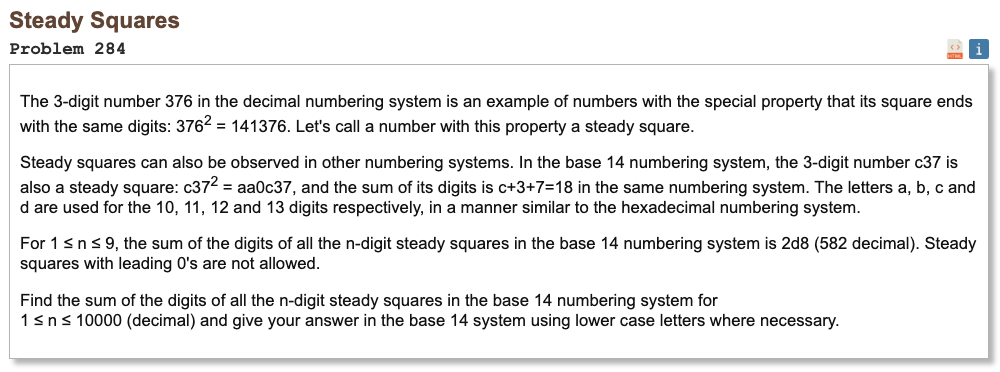

## Initial approach

* there are always four idempotent endings in base 14 at each length, but two are trivial, zero and one
* so the real work is following the two nontrivial branches that start from 7 and 8
* build each longer steady square one digit at a time from right to left, making sure the square still ends with the same digits after each extension
* sometimes the next added digit is zero, which means that branch does not create a new number of that length, so you should not count it there
* keep a running digit sum for each branch, and only add it to the total when the current value truly has that many digits
* include the single digit value 1 separately, since it is the only nontrivial trivial-case contribution that matters
* convert the final total to base 14 using lowercase letters at the end

In [1]:
def to_base_14(n):
    digits = "0123456789abcd"
    if n == 0:
        return "0"
    s = ""
    while n > 0:
        s = digits[n % 14] + s
        n //= 14
    return s

def solve(limit=10000):
    total = 1

    for start in (7, 8):
        x = start
        digit_sum = start
        length = 1
        total += digit_sum
        power = 14

        for n in range(1, limit):
            modulus = power * 14
            for d in range(14):
                y = x + d * power
                if (y * y - y) % modulus == 0:
                    x = y
                    if d != 0:
                        digit_sum += d
                        length = n + 1
                    break
            power = modulus
            if length == n + 1:
                total += digit_sum

    return to_base_14(total)

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 5a411d7b
CPU times: user 2min 52s, sys: 285 ms, total: 2min 52s
Wall time: 2min 52s
